In [1]:
%load_ext autoreload
%autoreload 2
import logging
from pathlib import Path

from src import Network, connect
from src.utils import get_simulation_data, obtain_rms_results

logging.basicConfig(level=logging.INFO, format='%(name)s - %(levelname)s - %(message)s')


NOTEBOOK_DIR = Path.cwd()
RMS_RESULTS_PATH = NOTEBOOK_DIR / "rms_results_with_loads_constZ"
PROJECT_NAME = "2025 PoSyDyS\\25_bus_meshed_system_CLS"
PFapp = connect(PROJECT_NAME, show=True)

In [2]:
# ###### SET settings for the grid ######
# # 1. Set loads to constant impedance 
# # 2. Set generators to Classical Model
# from typing import List

# # 1. Set loads to constant impedance
# loadObjects: List[pf.DataObject] = PFapp.GetCalcRelevantObjects('*.ElmLod')
# for load in loadObjects:
#     loadType = load.GetAttribute('typ_id')
#     loadType.SetAttribute('lodst', 100)  # Static Z attribute
#     loadType.SetAttribute('loddy', 0)  # Dynamic load disabled

# # 2. Set generators to Classical Model
# synMachines: List[pf.DataObject] = PFapp.GetCalcRelevantObjects('*.ElmSym')
# for machine in synMachines:
#     mType = machine.GetAttribute('typ_id')
#     mType.SetAttribute('model_inp', "cls")  # Classical Model
#     mType.SetAttribute('xstr', 0.2)  # Classical Model


In [3]:
PFapp.Hide()
PFapp.ResetCalculation()
sim_config = {"sim_time": 1.0, "event_time": 0.5, "timestep": 1}  # ms
obtain_rms_results(PFapp, str(RMS_RESULTS_PATH), "All calculations", simConfig=sim_config)
PFapp.ResetCalculation()
PFapp.Show()

Results object: All calculations
All generators found: 25
Active generators: ['SG 41', 'SG 31', 'SG 51', 'SG 52', 'SG 53', 'SG 45', 'SG 35', 'SG 25', 'SG 15', 'SG 14', 'SG 12', 'SG 13', 'SG 42', 'SG 43', 'SG 44', 'SG 32', 'SG 34', 'SG 24', 'SG 33', 'SG 55', 'SG 54', 'SG 11', 'SG 21', 'SG 23', 'SG 22']
All voltage sources found: 0
Active voltage sources: []
All external grids found: 0
Active external grids: []
Processing generator outage 1: SG 41
Processing generator outage 2: SG 31
Processing generator outage 3: SG 51
Processing generator outage 4: SG 52
Processing generator outage 5: SG 53
Processing generator outage 6: SG 45
Processing generator outage 7: SG 35
Processing generator outage 8: SG 25
Processing generator outage 9: SG 15
Processing generator outage 10: SG 14
Processing generator outage 11: SG 12
Processing generator outage 12: SG 13
Processing generator outage 13: SG 42
Processing generator outage 14: SG 43
Processing generator outage 15: SG 44
Processing generator outag

In [4]:

# Initialize network from PowerFactory
net = Network(PFapp, base_mva=100.0, simplify_topology=False)
net.run_load_flow()

Network extracted:
  Lines:              40
  Generators:         25
  Loads:              25
  Buses:              25


True

In [5]:
# Now apply code to calculate synchronizing power coefficients and power distribution ratios
DIST_GEN = "SG 12"  # <-- Enter generator name here
MODE = 1

# Calculate power distribution ratios (returns ratios and matching gen names)
ratios, sources_name_order, sources_types = net.calculate_power_ratios(DIST_GEN, MODE=MODE)

# Filter to keep only generator entries (since voltage sources mesurements are not available since they present equvialent of the grid)
sync_mask = [t == "generator" for t in sources_types]
sources_name_order = [name for name, m in zip(sources_name_order, sync_mask) if m]
ratios = ratios[sync_mask]

In [6]:
import numpy as np

AVAILABLE_MEASUREMENTS = sources_name_order.copy() # ALL generators have measurements in this case
# Filter out measurements that don't exist in sources_name_order
not_in_sources_name_order = [gen for gen in AVAILABLE_MEASUREMENTS if gen not in sources_name_order]
if not_in_sources_name_order:
    print(f"Generators not in sources_name_order (removed): {not_in_sources_name_order}")
    AVAILABLE_MEASUREMENTS = [gen for gen in AVAILABLE_MEASUREMENTS if gen in sources_name_order]

# Get the simulation data with loads (now includes voltages)
rdP, simulation_gen_order, _ = get_simulation_data(
    DIST_GEN, 
    f"{RMS_RESULTS_PATH}/results_izpad_{DIST_GEN}.csv", 
    AVAILABLE_MEASUREMENTS,
    "All calculations", 
    dist_index=504
)

# Reorder rdP to match sources_name_order
rdP_reordered = np.array([rdP[simulation_gen_order.index(gen)] if gen in simulation_gen_order else np.nan for gen in sources_name_order])

Original lengths - rdP_reordered: 25, ratios: 25
Filtered lengths - generators: 25, rdP: 25, ratios: 25
Available measurements: ['SG 11', 'SG 12', 'SG 13', 'SG 14', 'SG 15', 'SG 21', 'SG 22', 'SG 23', 'SG 24', 'SG 25', 'SG 31', 'SG 32', 'SG 33', 'SG 34', 'SG 35', 'SG 41', 'SG 42', 'SG 43', 'SG 44', 'SG 45', 'SG 51', 'SG 52', 'SG 53', 'SG 54', 'SG 55']
99.99999999999997 100.0
[15.89701844  0.         11.81610895  5.35963843  3.27122873  8.82865528
 10.49704547  6.41253171  3.58391978  2.45588294  4.62215084  4.59127085
  3.36898721  2.2166039   1.69681059  2.45588294  2.27068925  1.83218873
  1.35779479  1.1367874   1.65077783  1.49562944  1.27044463  1.01477155
  0.89718031]


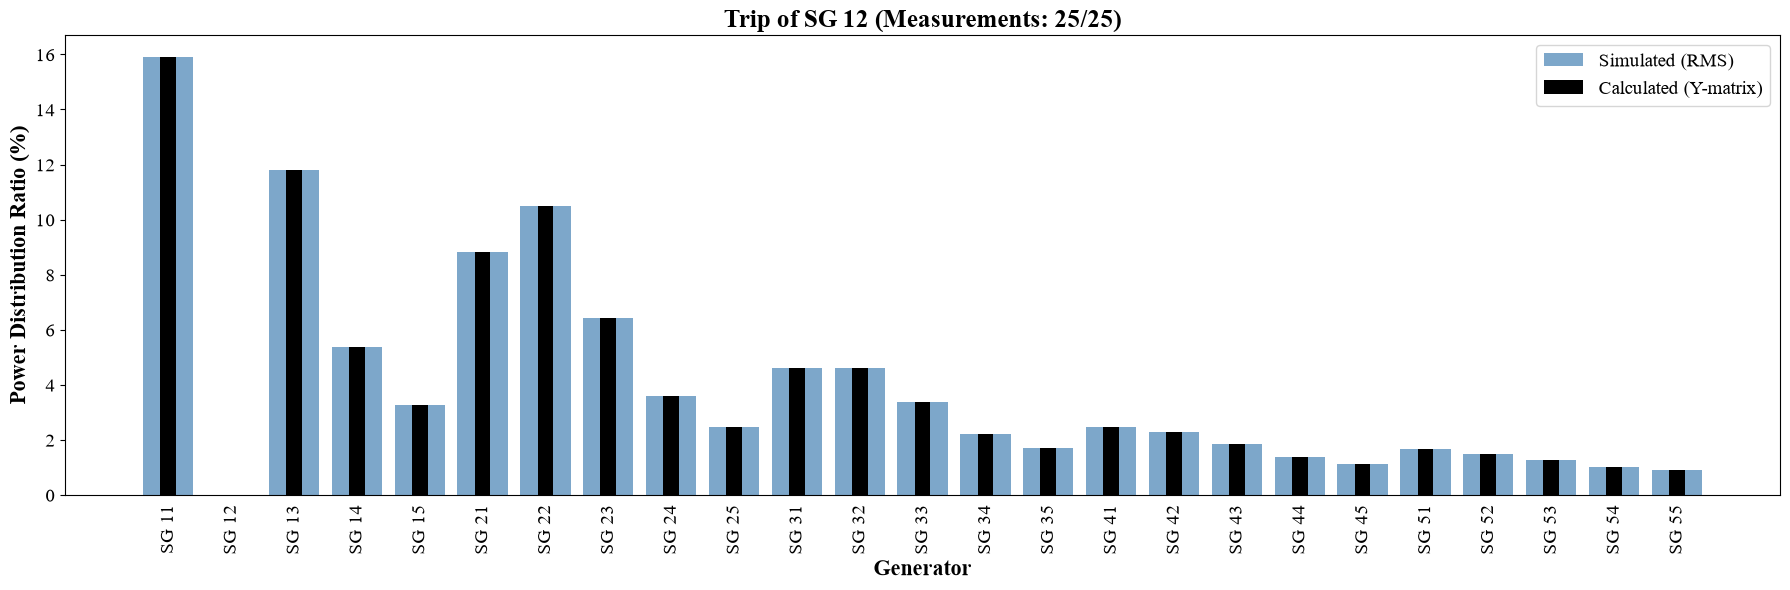


=== Comparison Statistics ===
Mean absolute error: 0.00%
Max absolute error: 0.00%
Correlation coefficient: 1.0000


In [7]:
# Plot the synched_simulation_data values
import matplotlib.pyplot as plt

# Set font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['svg.fonttype'] = 'none'  # Embed fonts as text, not paths

print(f"Original lengths - rdP_reordered: {len(rdP_reordered)}, ratios: {len(ratios)}")

# Filter to only include available measurements (non-NaN values)
# Create mask for available measurements
available_mask = ~np.isnan(rdP_reordered)
available_indices = np.where(available_mask)[0]

# Filter generator names, rdP, and ratios to only available measurements
generator_names_filtered = [sources_name_order[i] for i in available_indices]
rdP_filtered = rdP_reordered[available_mask]
ratios_filtered = np.array([ratios[i] for i in available_indices])

print(f"Filtered lengths - generators: {len(generator_names_filtered)}, rdP: {len(rdP_filtered)}, ratios: {len(ratios_filtered)}")
print(f"Available measurements: {generator_names_filtered}")

# Renormalize both to sum to 100%
rdP_sum = np.sum(rdP_filtered)
ratios_sum = np.sum(ratios_filtered)

rdP_normalized = (rdP_filtered / rdP_sum) * 100 if rdP_sum > 0 else rdP_filtered
ratios_normalized = (ratios_filtered / ratios_sum) * 100 if ratios_sum > 0 else ratios_filtered

print(sum(rdP_normalized), sum(ratios_normalized))
print(ratios_normalized)
# Plot only available measurements (renormalized)
plt.figure(figsize=(18, 6))
bar2 = plt.bar(generator_names_filtered, rdP_normalized, 0.8, color='steelblue', label='Simulated (RMS)', alpha=0.7)
bar1 = plt.bar(generator_names_filtered, ratios_normalized, 0.25, color='black', label='Calculated (Y-matrix)', alpha=1)
plt.xlabel('Generator', fontsize=16, fontweight='bold')
plt.ylabel('Power Distribution Ratio (%)', fontsize=16, fontweight='bold')
plt.title(f'Trip of {DIST_GEN} (Measurements: {len(generator_names_filtered)}/{len(sources_name_order)})', 
          fontsize=18, fontweight='bold')
plt.xticks(rotation=90, fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(axis='x', which='both', bottom=False, top=False)
plt.grid(False)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

# Print comparison statistics
print(f"\n=== Comparison Statistics ===")
print(f"Mean absolute error: {np.mean(np.abs(rdP_normalized - ratios_normalized)):.2f}%")
print(f"Max absolute error: {np.max(np.abs(rdP_normalized - ratios_normalized)):.2f}%")
print(f"Correlation coefficient: {np.corrcoef(rdP_normalized, ratios_normalized)[0,1]:.4f}")